In [62]:
import tifffile
import aicsimageio as aics
import os
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py
import dask.array as da
import napari
import glob
import sys
from skimage.morphology import binary_dilation, binary_erosion
import matplotlib as mpl
import seaborn as sns
import re

mpl.rcParams['axes.labelsize'] = 30
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['axes.titlesize'] = 30

# Colors
colors = list(plt.cm.tab20.colors)
colors += list(plt.cm.tab20b.colors)
all_partners_in_collection = ['At','AeCa','BrVe','CiFr','G3','GN1','GN3','GN4','Ct','G1','G4','G5','G6','G8','AlFa','KlPn','PsFu','PsAe','PsFl','PsPs','PrRe','S1','S2','S5','SC1','SC12','SC14','SC18']
colors = colors[:len(all_partners_in_collection)]
color_dict = dict(zip(all_partners_in_collection, colors))

# Global variables
media = ["FAT", "FA"]
media_titles = ["FAT", "FA"]
nmedia = 2
nreplicates=3
chan_r = 0
chan_g = 1

# Setup folders 
proj_dir = pathlib.Path(os.getcwd()).parent.parent

raw_data_dir = proj_dir / 'raw_data' / '20240205_D5_SET1'
proc_data_dir = proj_dir / 'processed_data' / '20240205_D5_SET1'

if not os.path.exists(proc_data_dir):
   os.makedirs(proc_data_dir)

# Import functions
sys.path.insert(0, str(proj_dir / 'code'))
from _cfu_analysis_functions import *
from _image_analysis_functions import *
   

## Full colonies

In [ ]:
# Image paths
paths_full_fa = [p for p in glob.glob(str(raw_data_dir / "FullCols" / "*1.czi")) if "FAT" not in p and "OaAlone" not in p]
paths_full_fa = [p for p in paths_full_fa if "05X" not in p]
paths_full_fat = [p for p in glob.glob(str(raw_data_dir / 'FullCols' / '*1.czi')) if "FAT" in p and "OaAlone" not in p]
paths_full_fa.sort()
paths_full_fat.sort()
if len(paths_full_fa) != len(paths_full_fat):
    print(paths_full_fa)
    print(paths_full_fat)
    raise ValueError("Number of FA and FAT full colony images do not match.")
else:
    print(f"Found {len(paths_full_fa)} FA and FAT full colony images.")

Found 6 FA and FAT full colony images.


In [22]:
# Load images
ims_full_fa = [np.squeeze(aics.AICSImage(im_path).get_image_data()) for im_path in paths_full_fa]
ims_full_fat = [np.squeeze(aics.AICSImage(im_path).get_image_data()) for im_path in paths_full_fat]

# Get partner names from image paths
partners = [s.replace(str(raw_data_dir),'').replace('/FullCols/','') for s in paths_full_fa]
partners = [s.replace('FA1.czi','') for s in partners]
npartners = len(partners)
print(partners)

['At', 'Ct', 'SC12', 'SC14', 'SC18', 'SC1']


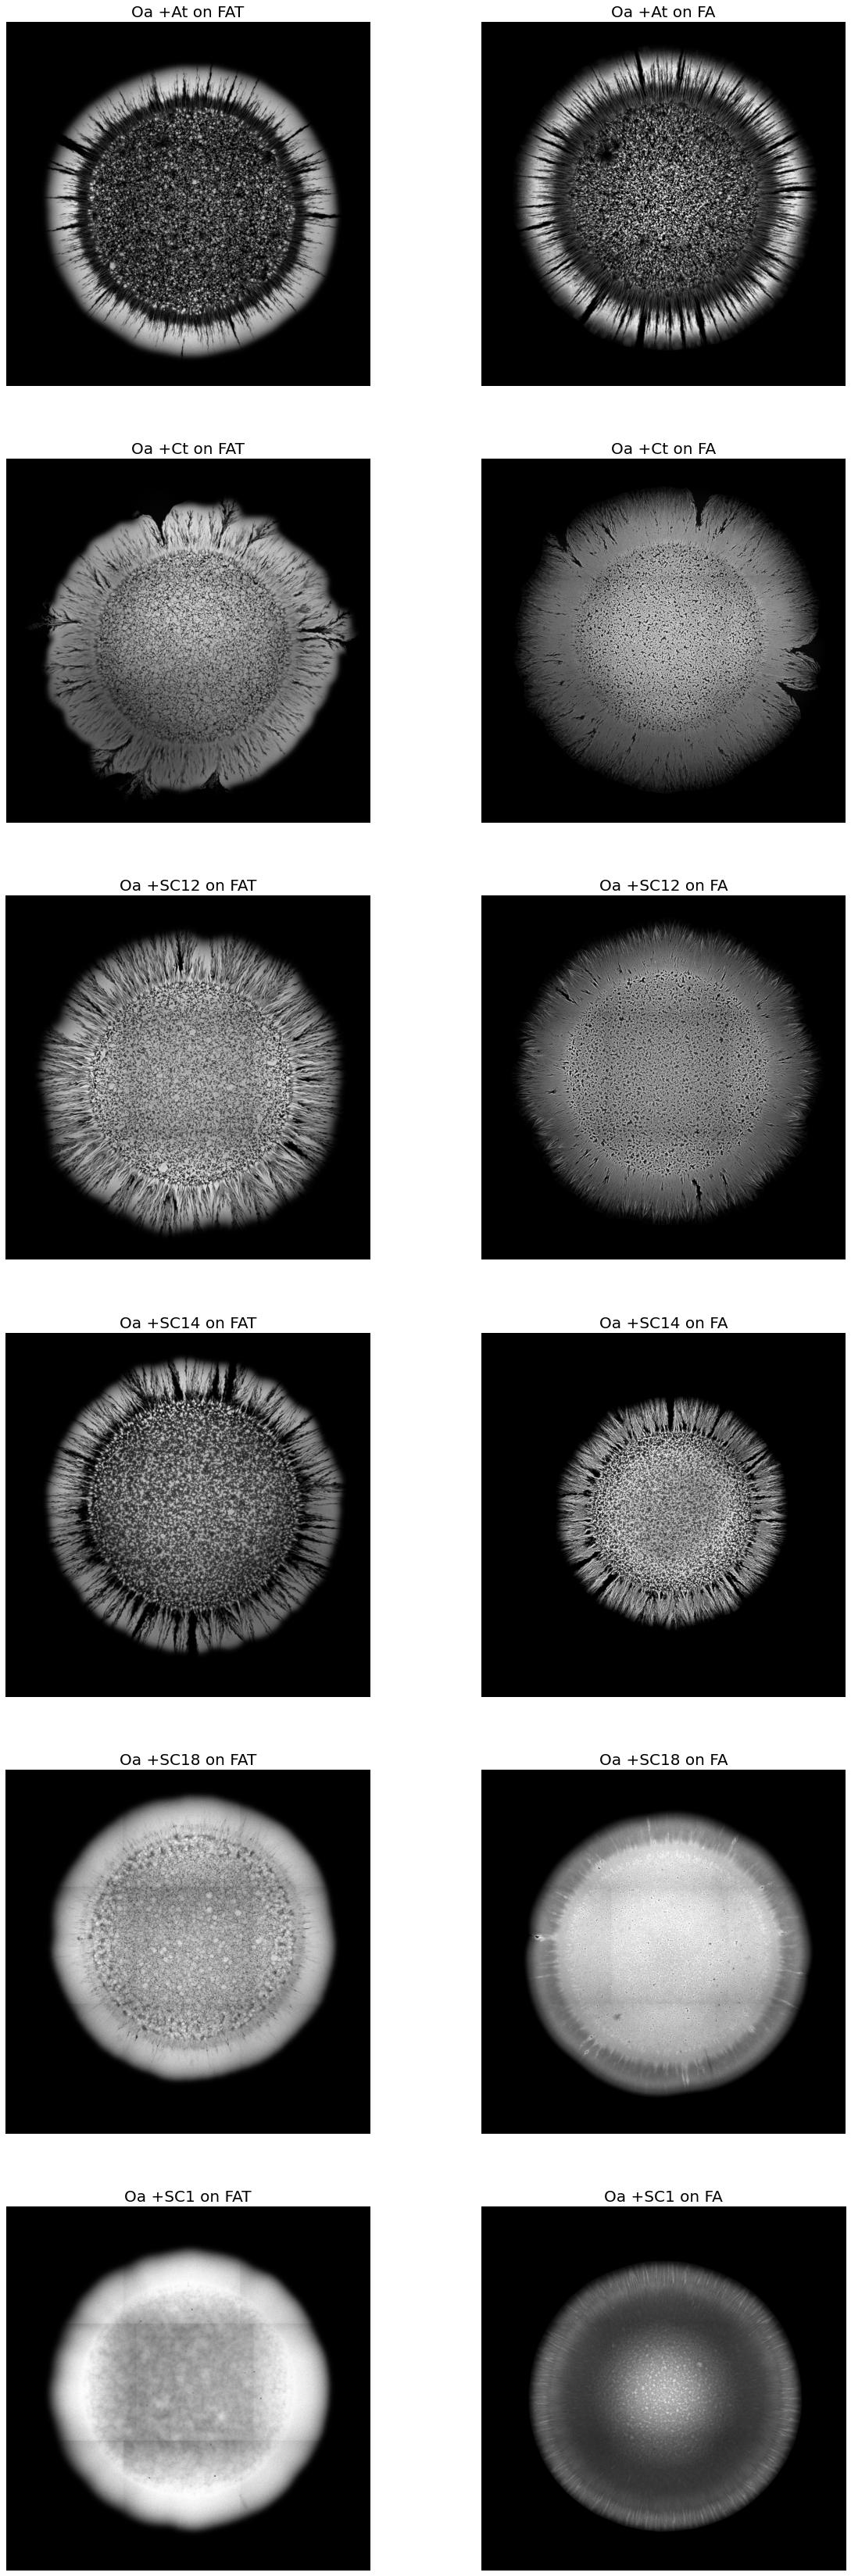

In [23]:
# Plot full colonies
option = "vertical"
if option == "vertical":
    fig, ax = plt.subplots(nrows=npartners, ncols=2, figsize=(20, 10*npartners))
    for i in range(npartners):
        ax[i,0].imshow(ims_full_fat[i][chan_r,:,:],cmap="gray")
        ax[i,1].imshow(ims_full_fa[i][chan_r,:,:],cmap="gray")
        ax[i,0].set_title("Oa +" + partners[i] + " on " + media_titles[0],fontsize=20)
        ax[i,1].set_title("Oa +" + partners[i] + " on " + media_titles[1],fontsize=20)
        ax[i,0].axis('off')
        ax[i,1].axis('off')
    plt.show()
elif option == "horizontal":
    fig, ax = plt.subplots(nrows=2, ncols=npartners, figsize=(10*npartners, 20))
    for i in range(npartners):
        ax[0,i].imshow(ims_full_fat[i][chan_r,:,:],cmap="gray")
        ax[1,i].imshow(ims_full_fa[i][chan_r,:,:],cmap="gray")
        ax[0,i].set_title("Oa +" + partners[i],fontsize=30)
        ax[0,i].set_xticks([])
        ax[1,i].set_xticks([])
        ax[0,i].set_yticks([])
        ax[1,i].set_yticks([])
    ax[0,0].set_ylabel(media_titles[0],fontsize=30)
    ax[1,0].set_ylabel(media_titles[1],fontsize=30)
    plt.tight_layout()
    plt.show()

## Closeups
In the past I only analyzed the closeup images in 20240205_D5_SET1_images_for_analysis.ods i.e. only the first replicate. I normalized them and calculated the segmentation probabilities using Ilastik. The normalized images and Ilastik probabilities are saved in folder processed_data. Note that the replicate number (i.e. 1) is not added. I will now calculate the normalized images and Ilastik probabilities and save the new files indicating replicates 2 and 3.

In [26]:
# Setup image paths
img_path_df = pd.read_excel(raw_data_dir / '20240205_D5_SET1_images_for_analysis.ods', engine='odf')

paths_closeup_fa_1 = img_path_df["Path"][(img_path_df["Medium"]=="FA") & (img_path_df["Image type"]=="closeup 20X")]
paths_closeup_fat_1 = img_path_df["Path"][(img_path_df["Medium"]=="FAT") & (img_path_df["Image type"]=="closeup 20X")]

img_path_df

,Partner,Medium,Image type,Path
0,At,FAT,full 5X,FullCol/AtFAT1.czi
1,At,FA,full 5X,FullCol/AtFA1.czi
2,At,FAT,closeup 20X,CloseUps/AtFAT1.czi
3,At,FA,closeup 20X,CloseUps/AtFA1.czi
4,Ct,FAT,full 5X,FullCol/CtFAT1.czi
5,Ct,FA,full 5X,FullCol/CtFA1.czi
6,Ct,FAT,closeup 20X,CloseUps/CtFAT1.czi
7,Ct,FA,closeup 20X,CloseUps/CtFA1.czi
8,SC1,FAT,full 5X,FullCol/SC1FAT1.czi
9,SC1,FA,full 5X,FullCol/SC1FA1.czi


In [35]:
# Add replicate 2 and 3
paths_closeup_fa_2_3 = [p.replace("FA1.czi","FA2.czi") for p in paths_closeup_fa_1] + [p.replace("FA1.czi","FA3.czi") for p in paths_closeup_fa_1]
paths_closeup_fat_2_3 = [p.replace("FAT1.czi","FAT2.czi") for p in paths_closeup_fat_1] + [p.replace("FAT1.czi","FAT3.czi") for p in paths_closeup_fat_1]
paths_closeup_fa_2_3.sort()
paths_closeup_fat_2_3.sort()

In [29]:
# Get partner name
partner_names = pd.unique(img_path_df["Partner"])
print(paths_closeup_fa_1)
partner_names

3       CloseUps/AtFA1.czi
7       CloseUps/CtFA1.czi
11     CloseUps/SC1FA1.czi
15    CloseUps/SC12FA1.czi
19    CloseUps/SC14FA1.czi
23    CloseUps/SC18FA1.czi
Name: Path, dtype: object


array(['At', 'Ct', 'SC1', 'SC12', 'SC14', 'SC18'], dtype=object)

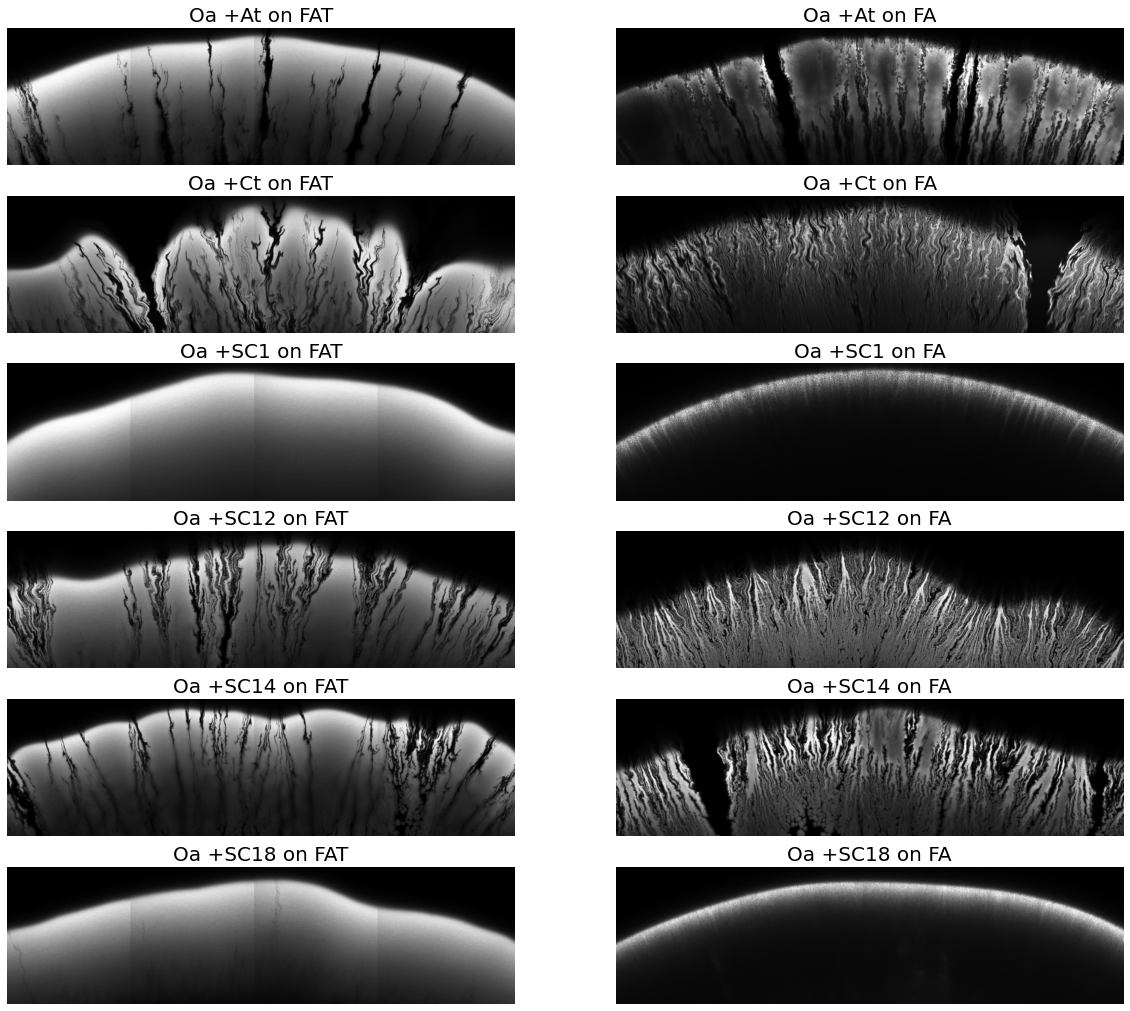

In [33]:
# Load and plot images from replicate 1
ims_closeup_fa_1 = [np.squeeze(aics.AICSImage(raw_data_dir / im_path).get_image_data()) for im_path in paths_closeup_fa_1]
ims_closeup_fat_1 = [np.squeeze(aics.AICSImage(raw_data_dir / im_path).get_image_data()) for im_path in paths_closeup_fat_1]

# Normalize (these are the ones that are saved in the processed data folder without the replicate number)
ims_closeup_fa_norm_1 = [normalize_image_global(img[chan_r]) for img in ims_closeup_fa_1]
ims_closeup_fat_norm_1 = [normalize_image_global(img[chan_r]) for img in ims_closeup_fat_1]

# Print normalized images
fig, ax = plt.subplots(npartners, 2, figsize=(10*2,3*npartners))
for i in range(npartners):
    ax[i,0].imshow(ims_closeup_fat_norm_1[i],cmap='gray')
    ax[i,1].imshow(ims_closeup_fa_norm_1[i],cmap='gray')
    ax[i,0].set_title("Oa +" + partner_names[i] + " on FAT",fontsize=20)
    ax[i,1].set_title("Oa +" + partner_names[i] + " on FA",fontsize=20)
    ax[i,0].axis('off')
    ax[i,1].axis('off')
plt.show()

In [46]:
# Load images for replicates 2 and 3
ims_closeup_fa_2_3 = [np.squeeze(aics.AICSImage(raw_data_dir / im_path).get_image_data()) for im_path in paths_closeup_fa_2_3]
ims_closeup_fat_2_3 = [np.squeeze(aics.AICSImage(raw_data_dir / im_path).get_image_data()) for im_path in paths_closeup_fat_2_3]

# Normalize them
ims_closeup_fa_norm_2_3 = [normalize_image_global(img[chan_r]) for img in ims_closeup_fa_2_3]
ims_closeup_fat_norm_2_3 = [normalize_image_global(img[chan_r]) for img in ims_closeup_fat_2_3]

# Save the normalized images for replicates 2 and 3
savenames_fa = [p.replace('CloseUps/','').replace('FA2.czi','_closeup_norm_fa2.tif') if 'FA2.czi' in p else p.replace('CloseUps/','').replace('FA3.czi','_closeup_norm_fa3.tif') for p in paths_closeup_fa_2_3]
savenames_fat = [p.replace('CloseUps/','').replace('FAT2.czi','_closeup_norm_fat2.tif') if 'FAT2.czi' in p else p.replace('CloseUps/','').replace('FAT3.czi','_closeup_norm_fat3.tif') for p in paths_closeup_fat_2_3]

for i in range(len(ims_closeup_fa_norm_2_3)):
    tifffile.imwrite(proc_data_dir / savenames_fa[i], ims_closeup_fa_norm_2_3[i])
    tifffile.imwrite(proc_data_dir / savenames_fat[i], ims_closeup_fat_norm_2_3[i])

## Thresholding test with ilastik probabilities for the 1st replicate

In [ ]:
# Load the original probabilities obtained for the first replicates
fat_prob_paths = [str(str(proc_data_dir) + "/" + partner + "_closeup_norm_fat_Probabilities.h5") for partner in partner_names]
fa_prob_paths = [str(str(proc_data_dir) + "/" + partner + "_closeup_norm_fa_Probabilities.h5") for partner in partner_names]

print(fat_prob_paths)
print(fa_prob_paths)

In [49]:
partner_idx = 3
fat_prob = h5py.File(fat_prob_paths[partner_idx], 'r')['exported_data'][:,:,0]
fa_prob = h5py.File(fa_prob_paths[partner_idx], 'r')['exported_data'][:,:,0]

In [ ]:
viewer = napari.view_image(ims_closeup_fa_1[partner_idx][chan_r],name='FA',colormap="red")
_ = viewer.add_image(fa_prob, name='FA - probs',colormap='gray')
_ = viewer.add_image(ims_closeup_fat_1[partner_idx][chan_r], name='FAT',colormap='red')
_ = viewer.add_image(fat_prob, name='FAT - probs',colormap='gray')
napari.run()

libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


In [ ]:
thresholds_to_try = np.linspace(0,1,101)

fa_thresh_stack = da.stack([fa_prob>t for t in thresholds_to_try],axis=0)
fat_thresh_stack = da.stack([fat_prob>t for t in thresholds_to_try],axis=0)
_ = viewer.add_image(fa_thresh_stack, name='FA - masks',colormap='gray')
_ = viewer.add_image(fat_thresh_stack, name='FAT - masks',colormap='gray')

In [54]:
chosen_thr = 80 #67
mask_fa = (fa_prob > thresholds_to_try[chosen_thr]).astype(int)
mask_fat = (fat_prob > thresholds_to_try[chosen_thr]).astype(int)
_ = viewer.add_image(mask_fa, name='FA - final mask',colormap='gray')
_ = viewer.add_image(mask_fat, name='FAT - final mask',colormap='gray')

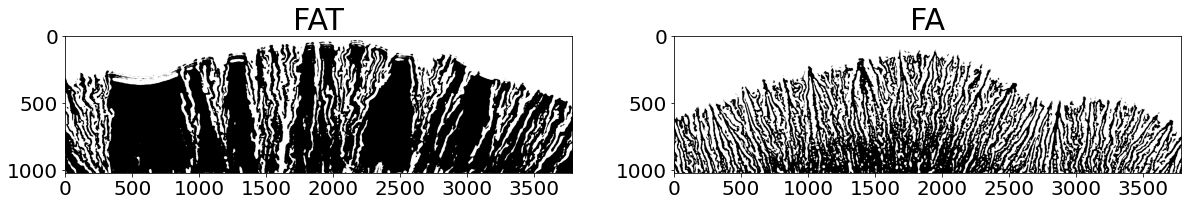

In [55]:
fig, ax = plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(mask_fat,cmap="Greys")
ax[1].imshow(mask_fa,cmap="Greys")
ax[0].set_title("FAT", fontsize=30)
ax[1].set_title("FA", fontsize=30)
plt.show()

## Load all probabilities and threshold them

In [64]:
# Load the probabilities for all replicates
# Account for the fact that the 1st replicate is the one that was already processed and saved without the replicate number, so we need to replace the first element of the lists with the original paths

fat_prob_paths = [str(str(proc_data_dir) + "/" + partner + f"_closeup_norm_fat{'' if i==1 else i}_Probabilities.h5") for partner in partner_names for i in range(1,nreplicates+1)]
fa_prob_paths = [str(str(proc_data_dir) + "/" + partner + f"_closeup_norm_fa{'' if i==1 else i}_Probabilities.h5") for partner in partner_names for i in range(1,nreplicates+1)]

def sort_key(path):
    name = pathlib.Path(path).name

    # matches fat_Probabilities, fat2_Probabilities, fat10_Probabilities
    # and same for fa
    m = re.search(r"_(fa|fat)(\d*)_Probabilities\.h5$", name)

    if m is None:
        return (name, 999999)

    medium, number = m.groups()

    # fa or fat without number should be replicate 1
    rep = int(number) if number else 1

    return (name.split(f"_{medium}")[0], medium, rep)

fat_prob_paths = sorted(fat_prob_paths, key=sort_key)
fa_prob_paths = sorted(fa_prob_paths, key=sort_key)


print(fat_prob_paths)
print(fa_prob_paths)

['/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/At_closeup_norm_fat_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/At_closeup_norm_fat2_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/At_closeup_norm_fat3_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/Ct_closeup_norm_fat_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/Ct_closeup_norm_fat2_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/Ct_closeup_norm_fat3_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/SC12_closeup_norm_fat_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5_SET1/SC12_closeup_norm_fat2_Probabilities.h5', '/home/alessia/Documents/PhD/Colony-project/processed_data/20240205_D5

In [65]:
# Load all probabilities
fat_prob = [h5py.File(p, 'r')['exported_data'][:,:,0] for p in fat_prob_paths]
fa_prob = [h5py.File(p, 'r')['exported_data'][:,:,0] for p in fa_prob_paths]
print(f"Loaded probabilities for {len(fat_prob)} FAT replicates and {len(fa_prob)} FA replicates.")

# Calculate masks
mask_fat = [(prob > thresholds_to_try[chosen_thr]).astype(int) for prob in fat_prob]
mask_fa = [(prob > thresholds_to_try[chosen_thr]).astype(int) for prob in fa_prob]

Loaded probabilities for 18 FAT replicates and 18 FA replicates.


In [ ]:
# Get partner names to match the order of the probabilities and masks 
partner_names = pd.unique(np.array([pathlib.Path(p).name.split("_closeup")[0] for p in fat_prob_paths]))

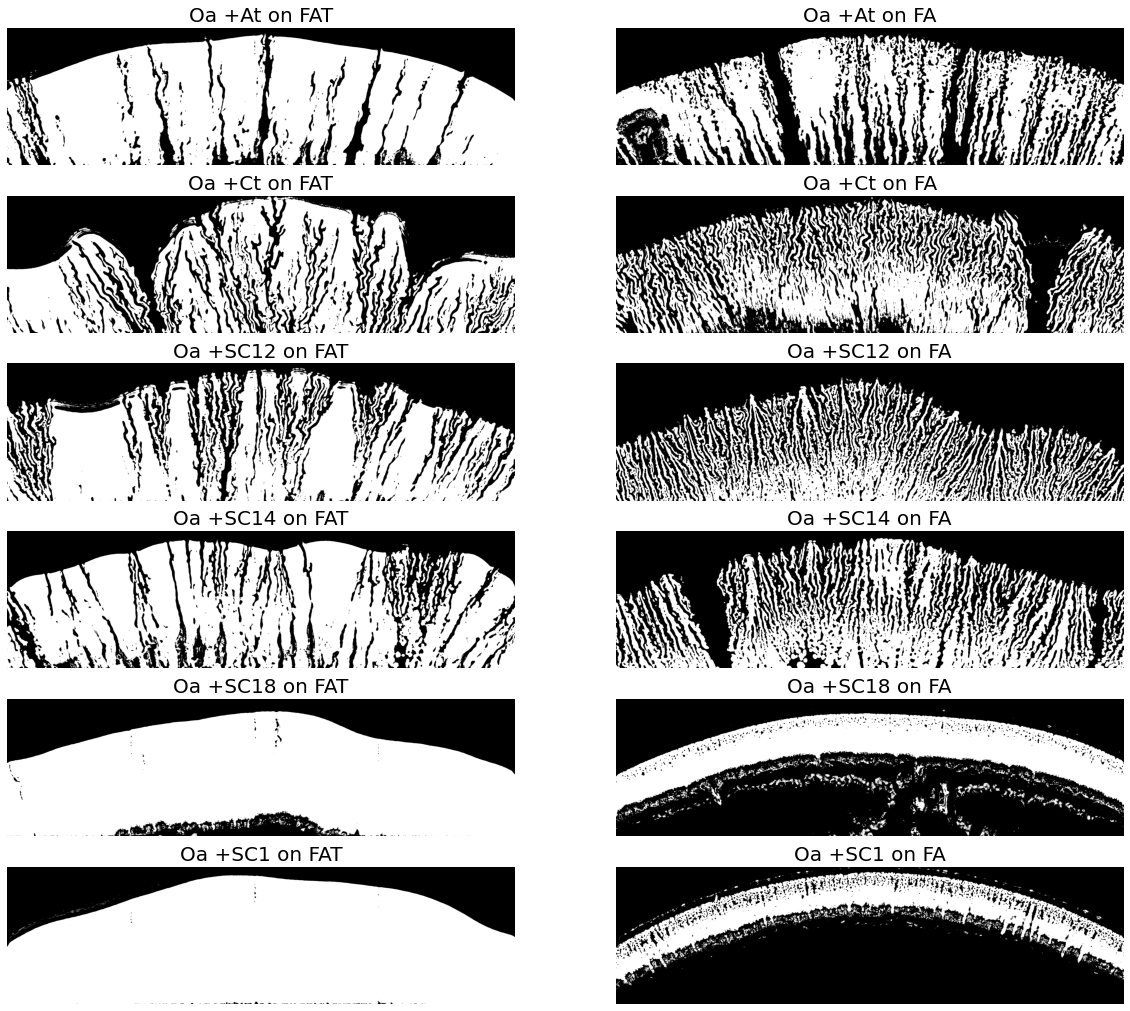

In [74]:
# Plot masks for first replicate
fig, ax = plt.subplots(npartners,2,figsize=(10*nmedia,3*npartners))
for i in range(npartners):
    ax[i,0].imshow(mask_fat[3*i],cmap='gray')
    ax[i,1].imshow(mask_fa[3*i],cmap='gray')
    ax[i,0].set_title("Oa +" + partner_names[i] + " on FAT",fontsize=20)
    ax[i,1].set_title("Oa +" + partner_names[i] + " on FA",fontsize=20)
    ax[i,0].axis('off')
    ax[i,1].axis('off')
plt.show()

## Determine full colony masks

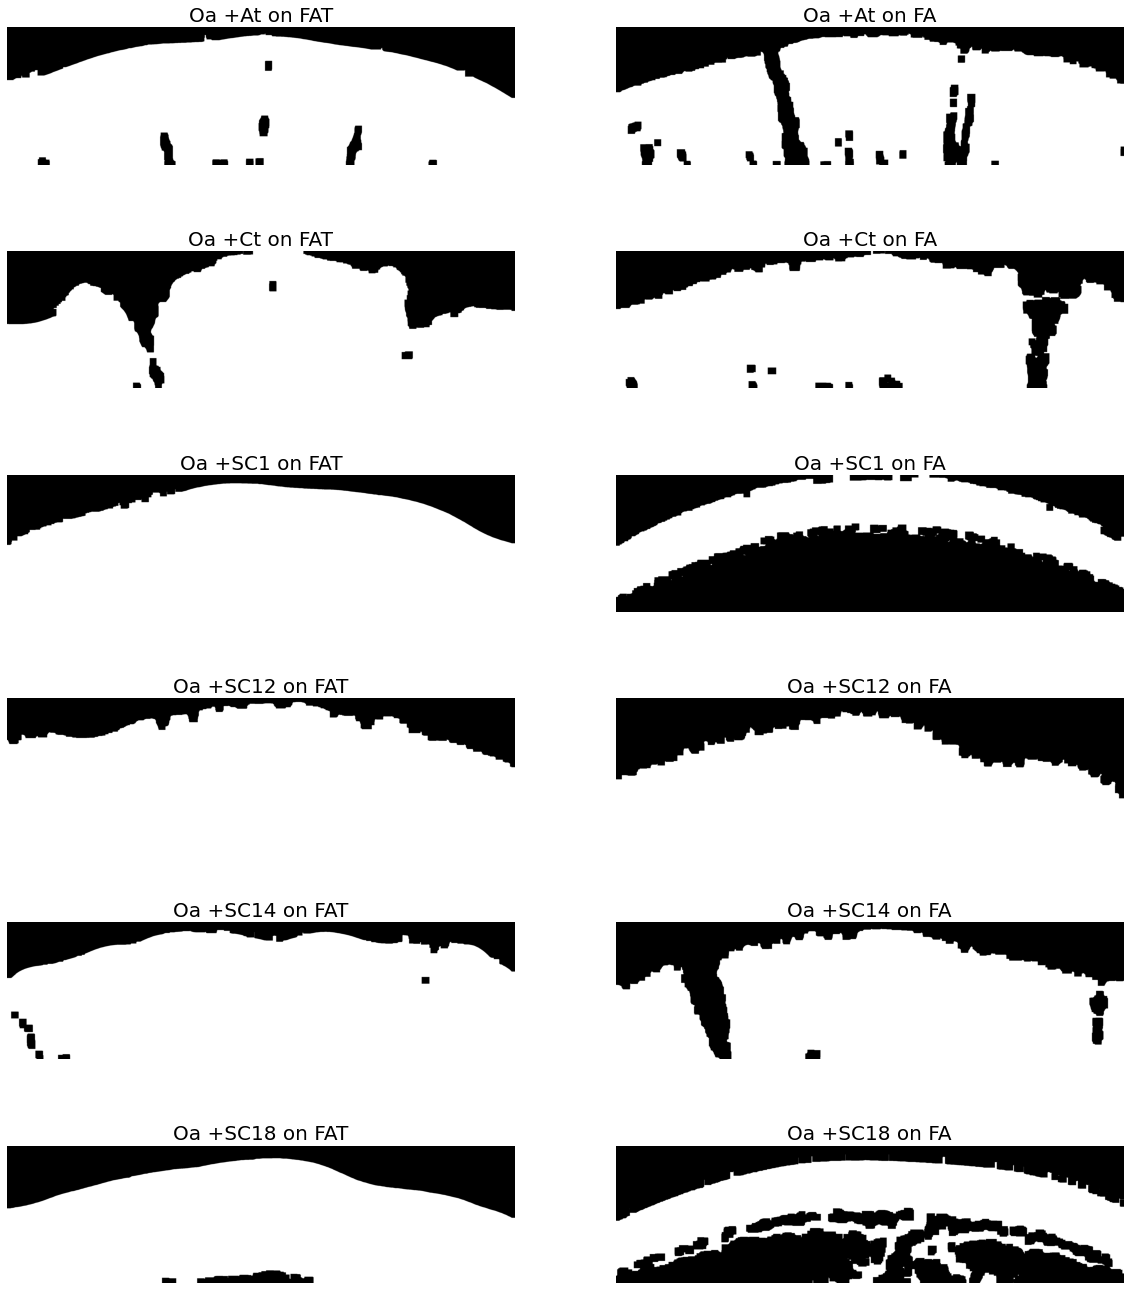

In [22]:
# Mask for each closeup

mask_full_fa = [binary_erosion(binary_dilation(im,footprint=np.ones((50,50))),footprint=np.ones((50,50))) for im in mask_fa]
mask_full_fat = [binary_erosion(binary_dilation(im,footprint=np.ones((50,50))),footprint=np.ones((50,50))) for im in mask_fat]

# Print masks
fig, ax = plt.subplots(n_partners, n_media, figsize=(10*n_media,4*n_partners))
for i in range(n_partners):
    ax[i,0].imshow(mask_full_fat[i],cmap='gray')
    ax[i,1].imshow(mask_full_fa[i],cmap='gray')
    ax[i,0].set_title("Oa +" + partner_names[i] + " on FAT",fontsize=20)
    ax[i,1].set_title("Oa +" + partner_names[i] + " on FA",fontsize=20)
    ax[i,0].axis('off')
    ax[i,1].axis('off')
plt.show()

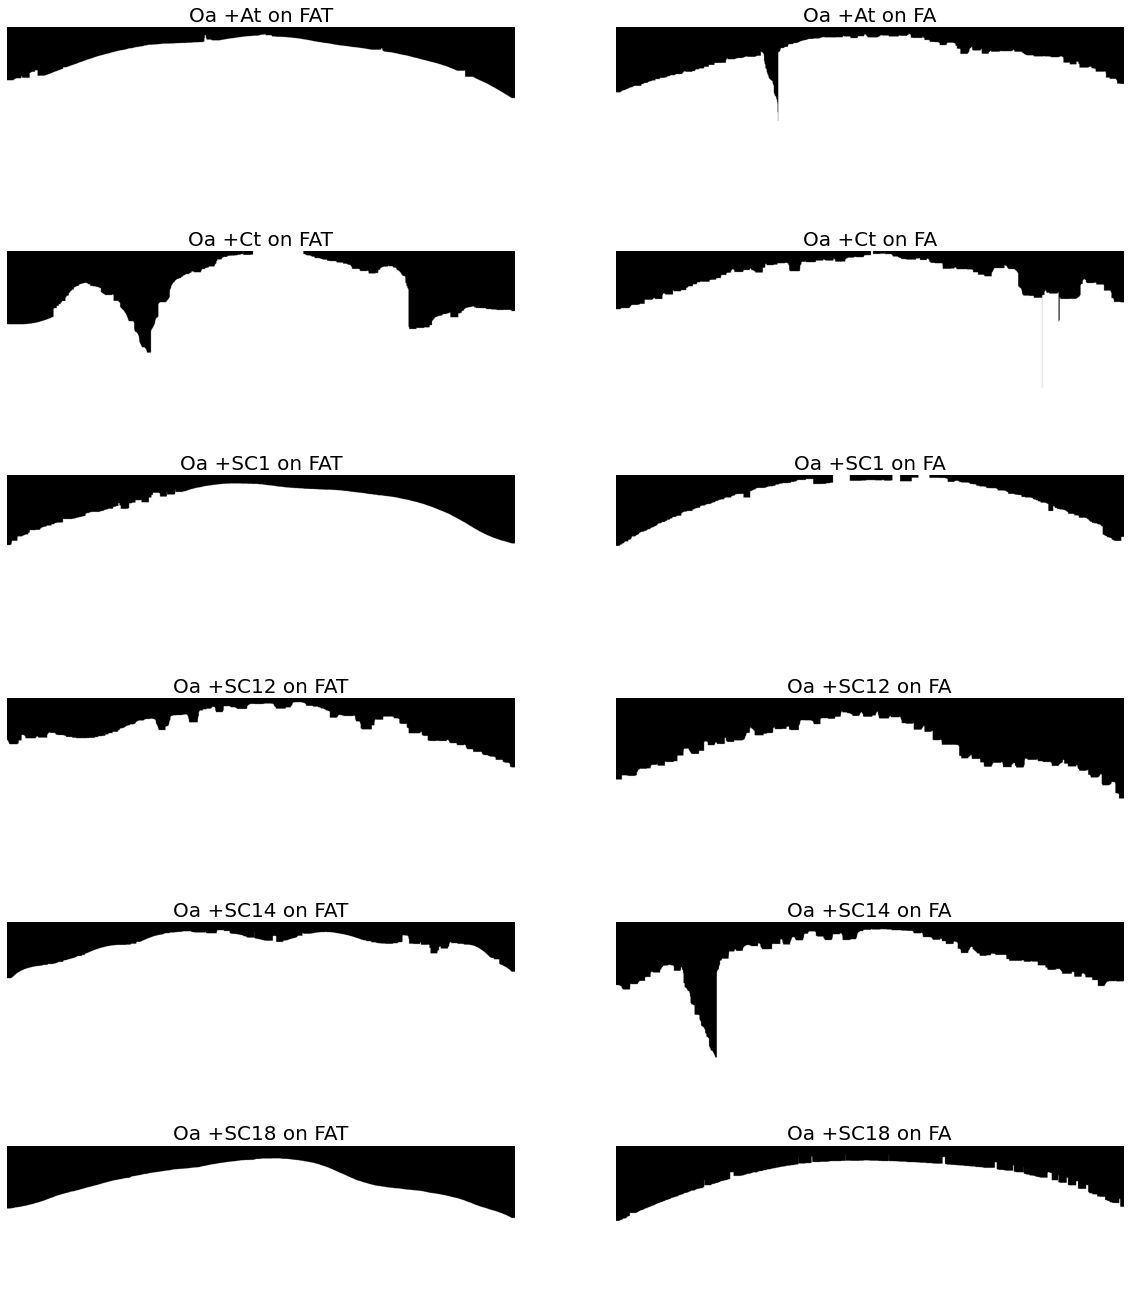

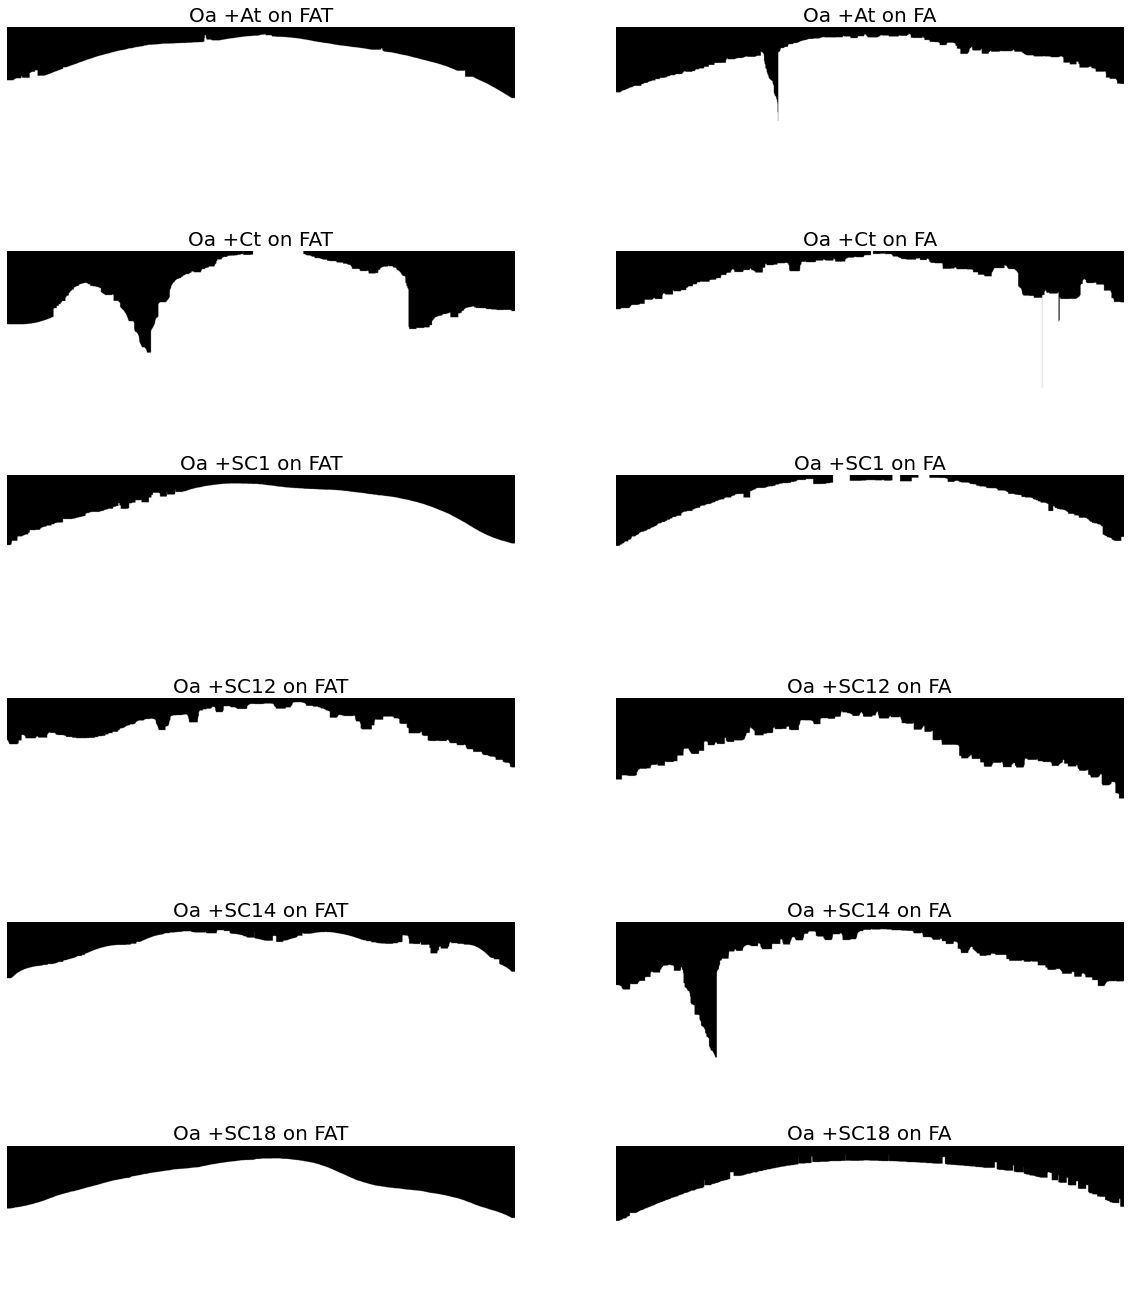

In [23]:
mask_full_fa_no_shadow = [remove_shadow_from_mask(im.astype(int)) for im in mask_full_fa]
mask_full_fat_no_shadow = [remove_shadow_from_mask(im.astype(int)) for im in mask_full_fat]

# Print masks
fig, ax = plt.subplots(n_partners, n_media, figsize=(10*n_media,4*n_partners))
for i in range(n_partners):
    ax[i,0].imshow(mask_full_fat_no_shadow[i],cmap='gray')
    ax[i,1].imshow(mask_full_fa_no_shadow[i],cmap='gray')
    ax[i,0].set_title("Oa +" + partner_names[i] + " on FAT",fontsize=20)
    ax[i,1].set_title("Oa +" + partner_names[i] + " on FA",fontsize=20)
    ax[i,0].axis('off')
    ax[i,1].axis('off')
plt.show()

## Select pixels for intermixing calculation and calculate intermixing

In [24]:
ii_fat = []
ii_fa = []
ss_oa_fat = []
ss_oa_fa = []
ss_p_fat = []
ss_p_fa = []
freq_fat = []
freq_fa = []

# FAT
for i in range(n_partners):

    # Get segmenttion mask and full colony mask
    seg_mask_fat = mask_fat[i]
    seg_mask_fa = mask_fa[i]
    full_colony_mask_fat = mask_full_fat[i].astype(bool)
    full_colony_mask_fa = mask_full_fa[i].astype(bool)

    # Determine pixel values
    pixels_fat = []
    pixels_fa = []

    for j in range(seg_mask_fat.shape[0]-1,-1,-1):
        pixels_fat.append(seg_mask_fat[j,full_colony_mask_fat[j,:]])
    for j in range(seg_mask_fa.shape[0]-1,-1,-1):
        pixels_fa.append(seg_mask_fa[j,full_colony_mask_fa[j,:]])

    pixels_fat = [x for x in pixels_fat if len(x) != 0]
    pixels_fa = [x for x in pixels_fa if len(x) != 0]

    # Calculate intermixing index, sector size and frequency
    ii_fat.append(intermixing_index(pixels_fat))
    ii_fa.append(intermixing_index(pixels_fa))
    ss_oa_fat_, ss_p_fat_, freq_fat_ = sector_size_and_freq(pixels_fat)
    ss_oa_fa_, ss_p_fa_,freq_fa_ = sector_size_and_freq(pixels_fa)
    ss_oa_fat.append(ss_oa_fat_)
    ss_oa_fa.append(ss_oa_fa_)
    ss_p_fat.append(ss_p_fat_)
    ss_p_fa.append(ss_p_fa_)
    freq_fat.append(freq_fat_)
    freq_fa.append(freq_fa_)

Density of Oa in colony: 0.888757
Density of Oa in colony: 0.683210


Density of Oa in colony: 0.733353
Density of Oa in colony: 0.595072
Density of Oa in colony: 0.981746
Density of Oa in colony: 0.631243
Density of Oa in colony: 0.751996
Density of Oa in colony: 0.548367
Density of Oa in colony: 0.788735
Density of Oa in colony: 0.610854
Density of Oa in colony: 0.961237
Density of Oa in colony: 0.689760


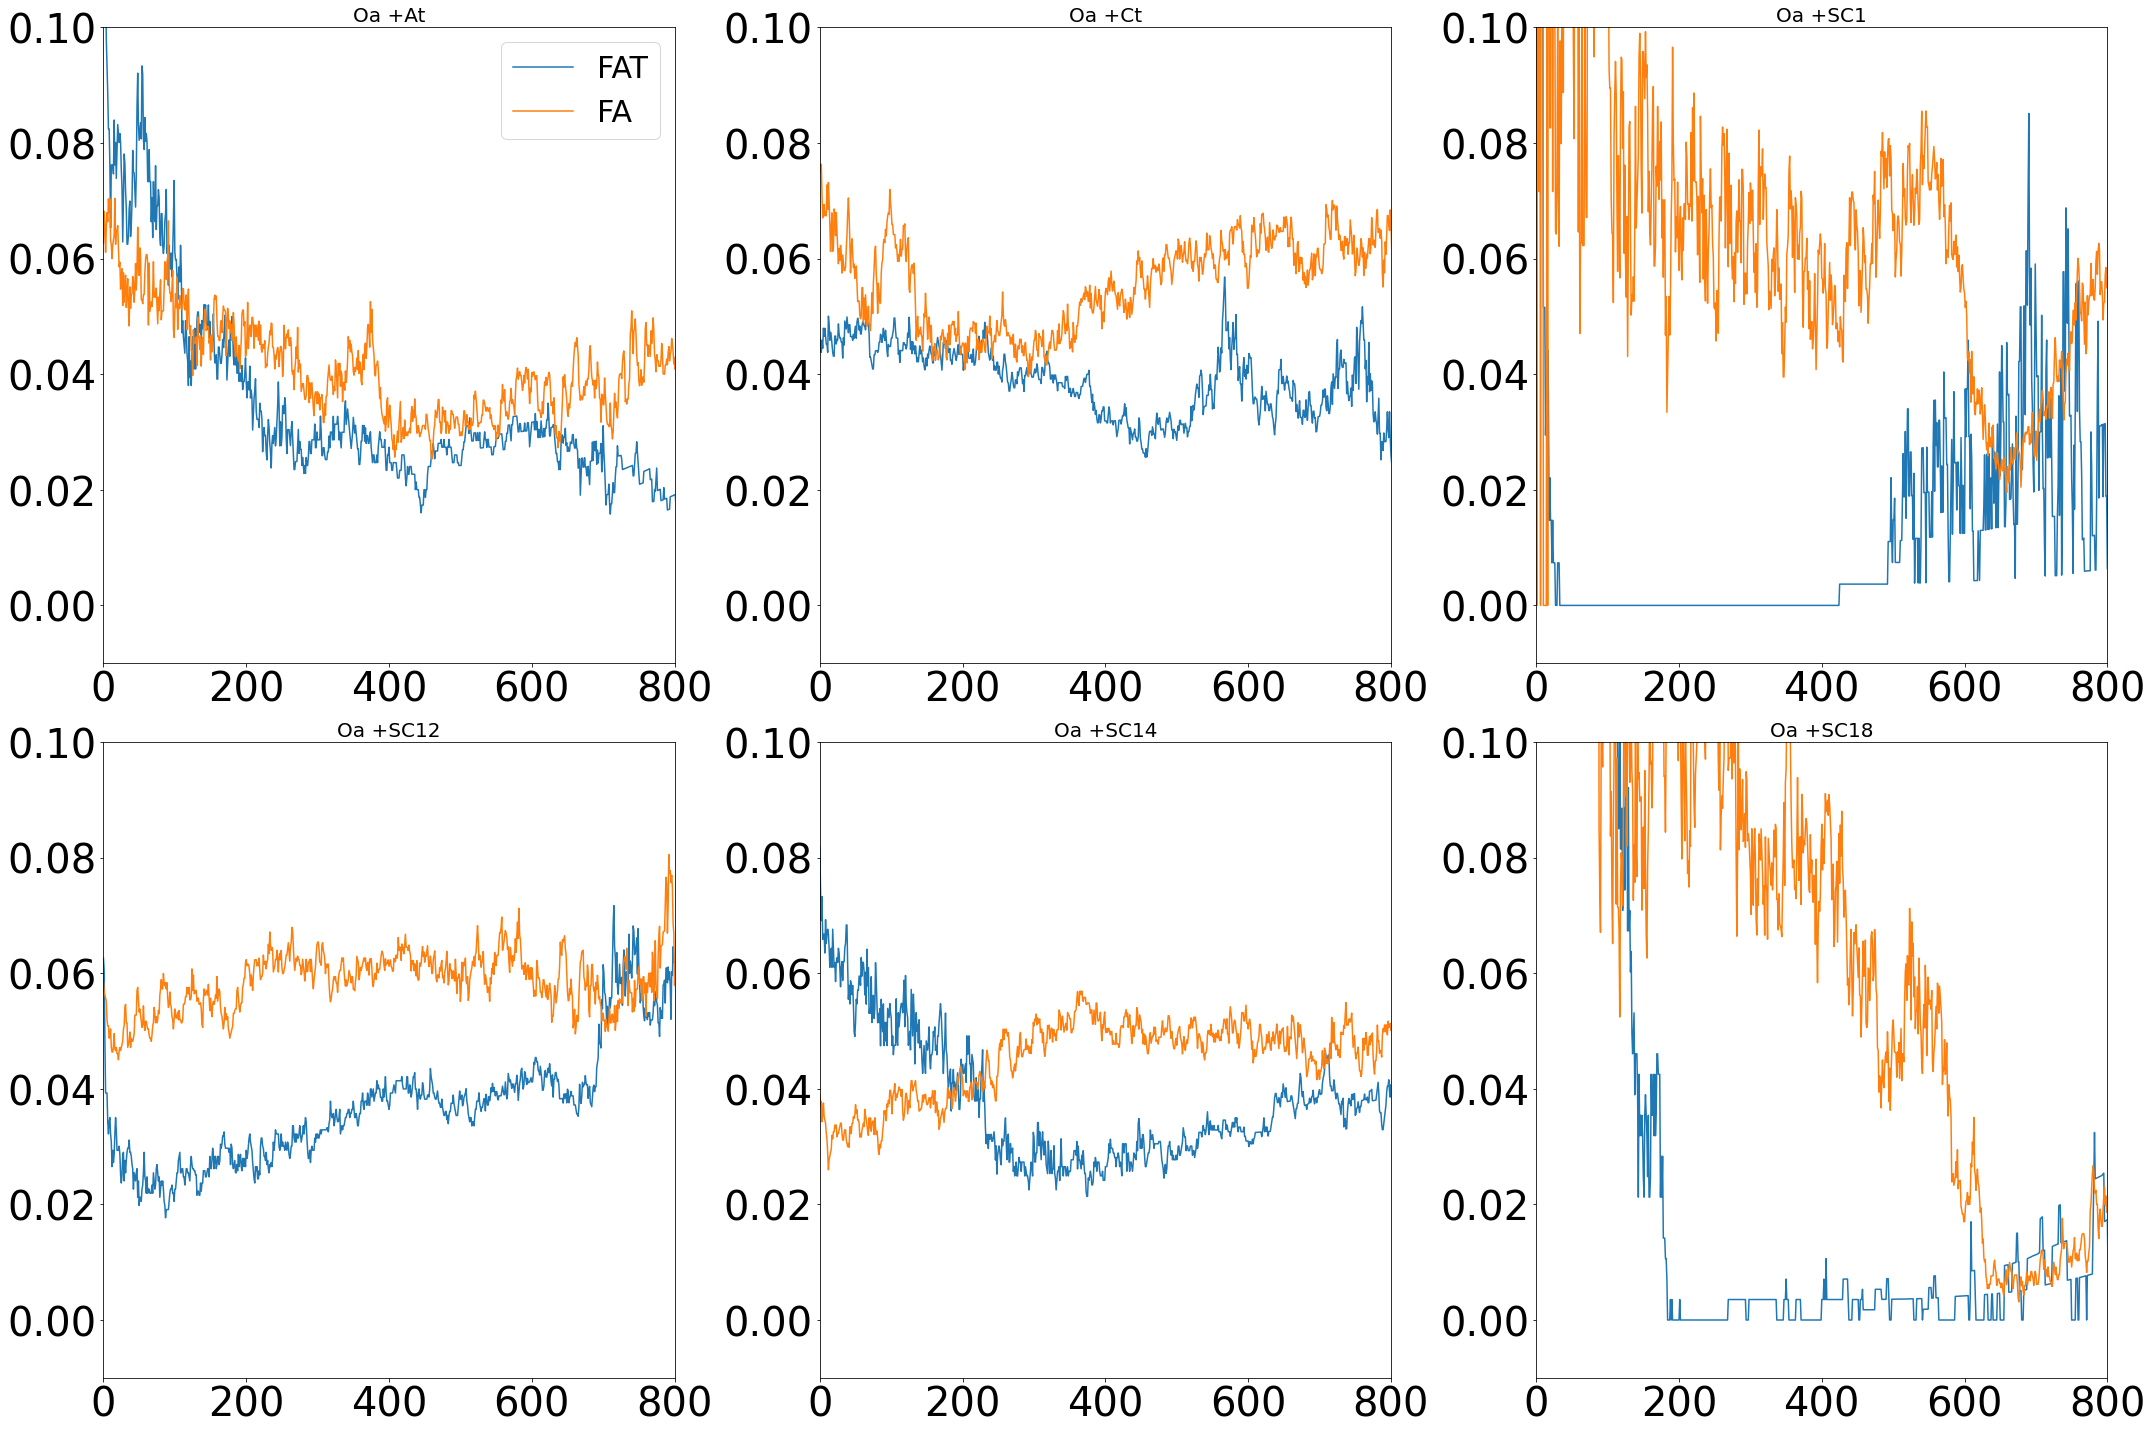

In [36]:
# Plot intermixing index in FA and FAT
fig, ax = plt.subplots(2,3,figsize=(30,20))
ax[0,0].plot(ii_fat[0],label="FAT")
ax[0,0].plot(ii_fa[0],label="FA")
ax[0,0].set_title("Oa +" + partner_names[0],fontsize=20)
ax[0,1].plot(ii_fat[1],label="FAT")
ax[0,1].plot(ii_fa[1],label="FA")
ax[0,1].set_title("Oa +" + partner_names[1],fontsize=20)
ax[0,2].plot(ii_fat[2],label="FAT")
ax[0,2].plot(ii_fa[2],label="FA")
ax[0,2].set_title("Oa +" + partner_names[2],fontsize=20)
ax[1,0].plot(ii_fat[3],label="FAT")
ax[1,0].plot(ii_fa[3],label="FA")
ax[1,0].set_title("Oa +" + partner_names[3],fontsize=20)
ax[1,1].plot(ii_fat[4],label="FAT")
ax[1,1].plot(ii_fa[4],label="FA")
ax[1,1].set_title("Oa +" + partner_names[4],fontsize=20)
ax[1,2].plot(ii_fat[5],label="FAT")
ax[1,2].plot(ii_fa[5],label="FA")
ax[1,2].set_title("Oa +" + partner_names[5],fontsize=20)

ax[0,0].legend(fontsize=30)
# axis ilmits
for i in range(2):
    for j in range(3):
        ax[i,j].set_ylim([-0.01,0.1])
        ax[i,j].set_xlim(0,800)
        #ax[1,j].set_xlabel("Pixel",fontsize=20)
        #ax[i,j].set_ylabel("Intermixing index",fontsize=20)
        ax[i,j].tick_params(axis='both', which='major', labelsize=40)
plt.tight_layout()
plt.show()

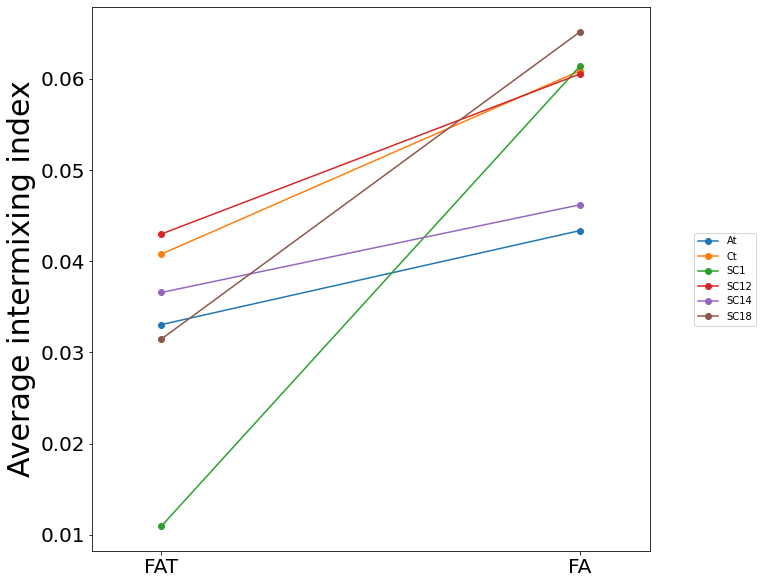

In [26]:
# Plot average intermixing in FAT and FA
fig, ax = plt.subplots(figsize=(10,10))
for i in range(n_partners):
    plt.plot([0.2,0.8],[np.mean(ii_fat[i][10:len(ii_fat[i])-10]), np.mean(ii_fa[i][10:len(ii_fa[i])-10])], '-o', label=partner_names[i])

ax.set_xticks([0.2,0.8])
ax.set_xlim([0.1,0.9])
ax.set_xticklabels(["FAT","FA"])
ax.set_ylabel("Average intermixing index")
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5))
plt.show()

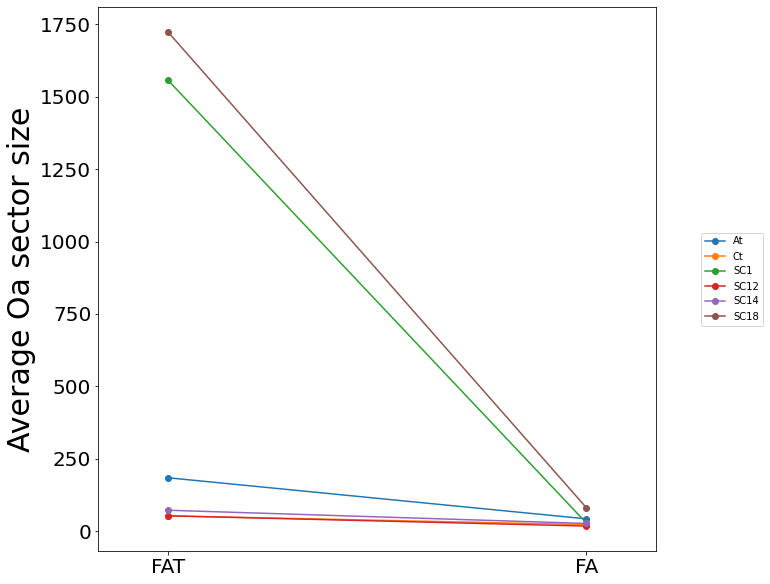

In [27]:
# Plot average sector size of Oa in FAT and FA
fig, ax = plt.subplots(figsize=(10,10))
for i in range(n_partners):
    plt.plot([0.2,0.8],[np.mean(ss_oa_fat[i][100:len(ss_oa_fat[i])-100]), np.mean(ss_oa_fa[i][100:len(ss_oa_fa[i])-100])], '-o', label=partner_names[i])

ax.set_xticks([0.2,0.8])
ax.set_xlim([0.1,0.9])
ax.set_xticklabels(["FAT","FA"])
ax.set_ylabel("Average Oa sector size")
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5))
plt.show()

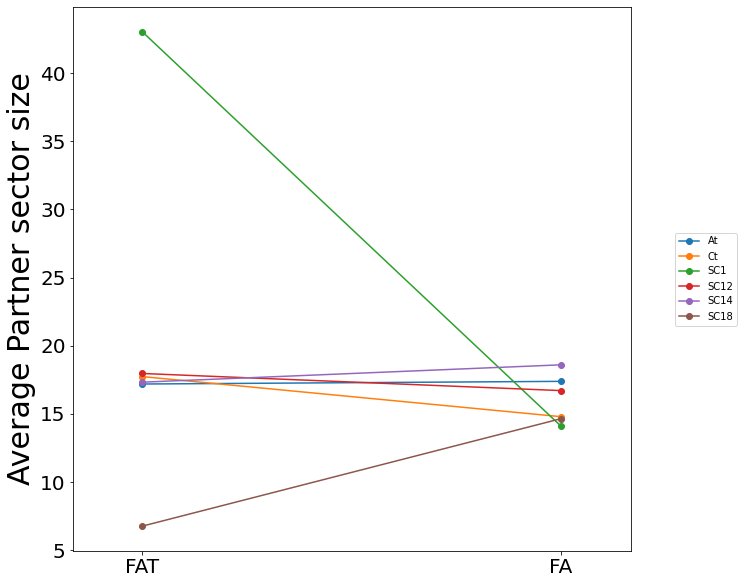

In [28]:
# Plot average sector size of P in FAT and FA
fig, ax = plt.subplots(figsize=(10,10))
for i in range(n_partners):
    plt.plot([0.2,0.8],[np.mean(ss_p_fat[i][100:len(ss_p_fat[i])-100]), np.mean(ss_p_fa[i][100:len(ss_p_fa[i])-100])], '-o', label=partner_names[i])
    
ax.set_xticks([0.2,0.8])
ax.set_xlim([0.1,0.9])
ax.set_xticklabels(["FAT","FA"])
ax.set_ylabel("Average Partner sector size")
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5))
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


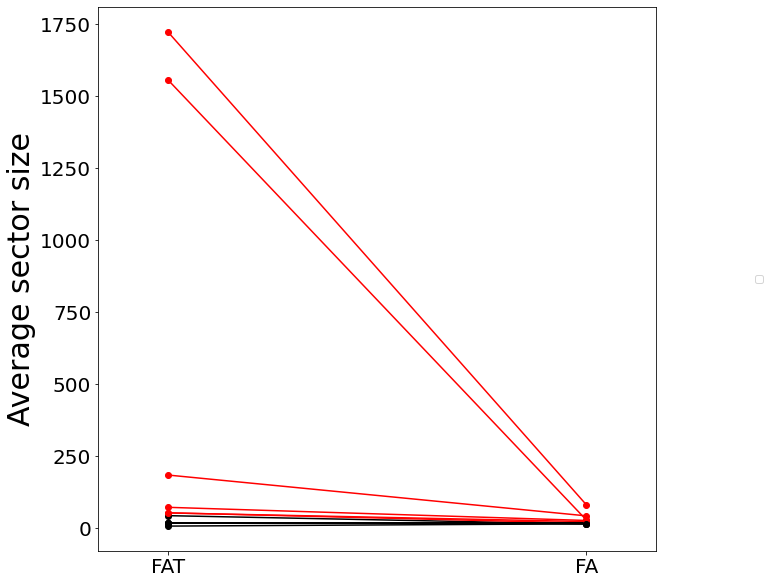

In [29]:
# Plot average sector size of Oa and P in FAT and FA
fig, ax = plt.subplots(figsize=(10,10))
for i in range(n_partners):
    plt.plot([0.2,0.8],[np.mean(ss_p_fat[i][100:len(ss_p_fat[i])-100]), np.mean(ss_p_fa[i][100:len(ss_p_fa[i])-100])], '-o', color="black")
    plt.plot([0.2,0.8],[np.mean(ss_oa_fat[i][100:len(ss_oa_fat[i])-100]), np.mean(ss_oa_fa[i][100:len(ss_oa_fa[i])-100])], '-o', color="red")
    
ax.set_xticks([0.2,0.8])
ax.set_xlim([0.1,0.9])
ax.set_xticklabels(["FAT","FA"])
ax.set_ylabel("Average sector size")
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5))
plt.show()

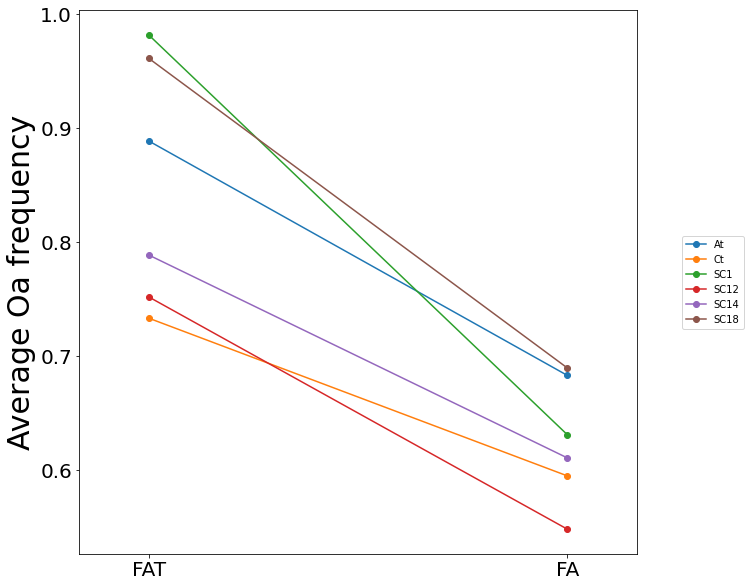

In [30]:
# Plot average frequency in FAT and FA
fig, ax = plt.subplots(figsize=(10,10))
for i in range(n_partners):
    plt.plot([0.2,0.8],[freq_fat[i], freq_fa[i]], '-o', label=partner_names[i])

ax.set_xticks([0.2,0.8])
ax.set_xlim([0.1,0.9])
ax.set_xticklabels(["FAT","FA"])
ax.set_ylabel("Average Oa frequency")
pos = ax.get_position()
ax.set_position([pos.x0, pos.y0, pos.width, pos.height])
ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5))
plt.show()

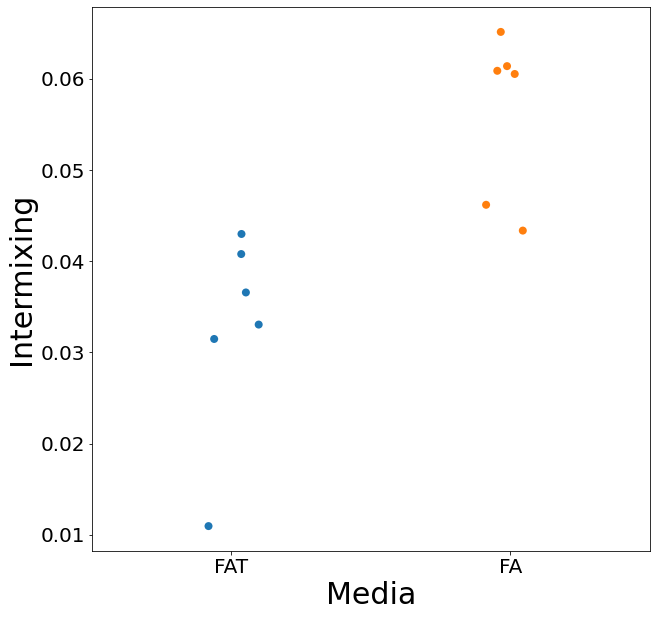

In [31]:
ii_df = pd.DataFrame({"Partner":np.concatenate((partner_names,partner_names)),"Media":np.concatenate((["FAT" for i in range(n_partners)],["FA" for i in range(n_partners)])), "Intermixing":np.concatenate(([np.mean(ii[10:len(ii)-10]) for ii in ii_fat],[np.mean(ii[10:len(ii)-10]) for ii in ii_fa]))})
fig, ax = plt.subplots(figsize=(10,10))
sns.stripplot(data=ii_df, y="Intermixing", x="Media",size=8)
plt.show()

In [32]:
ii_df = pd.DataFrame(columns=["Partner","Media","Intermixing","Oa sector size","Partner sector size","Oa frequency"])
ii_df["Partner"] = np.concatenate((partner_names,partner_names))
ii_df["Media"] = np.concatenate((["FAT" for i in range(n_partners)],["FA" for i in range(n_partners)]))
ii_df["Intermixing"] = np.concatenate(([np.mean(ii[10:len(ii)-10]) for ii in ii_fat],[np.mean(ii[10:len(ii)-10]) for ii in ii_fa]))
ii_df["Oa sector size"] = np.concatenate(([np.mean(ss_oa[100:len(ss_oa)-100]) for ss_oa in ss_oa_fat],[np.mean(ss_oa[100:len(ss_oa)-100]) for ss_oa in ss_oa_fa]))
ii_df["Partner sector size"] = np.concatenate(([np.mean(ss_p[100:len(ss_p)-100]) for ss_p in ss_p_fat],[np.mean(ss_p[100:len(ss_p)-100]) for ss_p in ss_p_fa]))
ii_df["Oa frequency"] = np.concatenate((freq_fat,freq_fa))
ii_df

,Partner,Media,Intermixing,Oa sector size,Partner sector size,Oa frequency
0,At,FAT,0.033061,184.201164,17.193076,0.888757
1,Ct,FAT,0.040795,52.586423,17.736043,0.733353
2,SC1,FAT,0.010968,1557.521815,43.024859,0.981746
3,SC12,FAT,0.042994,52.864308,17.965400,0.751996
4,SC14,FAT,0.036582,72.029144,17.328576,0.788735
5,SC18,FAT,0.031483,1724.147626,6.769740,0.961237
6,At,FA,0.043365,42.273555,17.388175,0.683210
7,Ct,FA,0.060884,22.423420,14.796864,0.595072
8,SC1,FA,0.061395,27.657032,14.103469,0.631243
9,SC12,FA,0.060536,17.258979,16.710481,0.548367


In [33]:
#save dataframe
ii_df.to_csv("intermixing_index_SET1.csv")